### Implementing R Threshold-Based Event Detection

In [1]:
from scipy.ndimage import gaussian_filter, median_filter
from scipy.signal import savgol_filter
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.widgets import Slider
from matplotlib.colors import TwoSlopeNorm
from scipy.interpolate import PchipInterpolator
import h5py
import cv2
import pandas as pd
from ipywidgets import HBox, VBox, IntSlider, Dropdown, Play, jslink, HTML, Layout
from IPython.display import display, clear_output
import os, time, re
import matplotlib.animation as animation
import imageio_ffmpeg
import cv2
from skimage.draw import polygon2mask
from skimage.measure import find_contours
from matplotlib.collections import LineCollection
from scipy import interpolate
from matplotlib.patches import Rectangle, FancyArrowPatch
%config InlineBackend.close_figures = False

from shared_functions import load_movie, mask_movie, find_trials

In [2]:
def analytic_signal_fft_nd(x, axis=-1):
    """
    FFT-based Hilbert transform to get analytic signal along a given axis.
    Works for real x with arbitrary extra dims.
    Returns complex analytic signal with same shape.
    """
    x = np.asarray(x)
    n = x.shape[axis]
    X = np.fft.fft(x, n=n, axis=axis)
    h = np.zeros(n, dtype=float)
    if n % 2 == 0:
        h[0] = 1.0
        h[n//2] = 1.0
        h[1:n//2] = 2.0
    else:
        h[0] = 1.0
        h[1:(n+1)//2] = 2.0
    # reshape h to broadcast along 'axis'
    shape = [1]*x.ndim
    shape[axis] = n
    H = h.reshape(shape)
    Z = np.fft.ifft(X * H, axis=axis)
    return Z

def gaussian_filter_nan(a, sigma, truncate=3.0, mode='reflect'):
    """
    NaN-aware Gaussian that (i) renormalizes by valid support and
    (ii) guarantees the output is NaN exactly where input is NaN.
    Works for (ny,nx) or (ny,nx,nt); use sigma like (sx,sy,0.0) for movies.
    """
    orig_valid = np.isfinite(a)
    a_filled   = np.where(orig_valid, a, 0.0).astype(float)

    # Constant padding avoids reflecting values across the mask boundary
    w = gaussian_filter(orig_valid.astype(float), sigma=sigma,
                        truncate=truncate, mode='constant', cval=0.0)
    b = gaussian_filter(a_filled, sigma=sigma,
                        truncate=truncate, mode='constant', cval=0.0)

    out = b / (w + 1e-12)
    # (i) keep NaNs where there was no valid support at all
    out[w < 1e-12] = np.nan
    # (ii) clamp to original mask: never “create” new pixels
    out[~orig_valid] = np.nan
    return out

def compute_phase(
    movie, Fs,
    sigma_px=1.0, truncate=3.0, mode='reflect',
    dx=1.0, dy=1.0
):
    """
    End-to-end analysis with the SAME methods as your current function:
      - Optional temporal bandpass (Butterworth, sosfiltfilt)
      - Analytic signal via analytic_signal_fft_nd
      - Amplitude & wrapped phase
      - Wrap-safe smoothing by normalizing to unit-magnitude complex, then Gaussian
      - Phase gradient via complex-product forward differences, sign-flipped (g = -∇φ)
      - Gradient magnitude

    Parameters
    ----------
    movie : (nt, ny, nx) real array
    Fs    : sampling rate (Hz)
    lo, hi, order : temporal bandpass parameters
    sigma_px, truncate, mode : spatial Gaussian params for complex smoothing
    dx, dy : pixel size (x,y)
    amp_mask : bool, apply your mask_low_amp() to z and amp
    bandpass : bool, apply bandpass before analytic signal
    identify_source : bool, compute argmax of divergence per frame for convenience
    gp : bool, whether to compute generalized phase

    Returns
    -------
    results : dict with keys:
        't', 'movie_bp', 'z', 'amp', 'phi', 'z_s',
        'gx', 'gy', 'grad_mag', 'div', 'curl', 'source'
    """
    nt, ny, nx = movie.shape
    t = np.arange(nt) / Fs

    # ---- 2) Analytic signal, amplitude, phase (unchanged) ----
    z = analytic_signal_fft_nd(movie, axis=0)
    amp = np.abs(z)

    # ---- Optional low-amp mask (unchanged) ----
    phi = np.angle(z)

    # ---- 3) Normalize amplitude ----
    eps = 1e-12
    
    # ---- Safe unit complex field: z_unit = z / amp ----
    # valid where both z and amp are finite and amp > eps
    valid = np.isfinite(z) & np.isfinite(amp) & (amp > eps)

    z_s = np.full_like(z, np.nan, dtype=np.complex128)     # preserves mask
    np.divide(z, amp, out=z_s, where=valid)             # no divide at invalids

    # ---- 4) Phase gradient via complex-product forward diffs (unchanged) ----
    # gx ~ angle( z(x+1,y) * conj(z(x,y)) ) / dx ; same for gy, then sign flip for g = -∇φ
    z_xp1 = np.roll(z_s, -1, axis=2)
    dphi_x = np.angle(z_xp1 * np.conj(z_s))
    gx = dphi_x / dx
    gx[:, :, -1] = np.nan  # invalidate forward edge

    z_yp1 = np.roll(z_s, -1, axis=1)
    dphi_y = np.angle(z_yp1 * np.conj(z_s))
    gy = dphi_y / dy
    gy[:, -1, :] = np.nan  # invalidate forward edge

    # Convention match: g = -∇φ
    gx, gy = -gx, -gy
    grad_mag = np.sqrt(gx**2 + gy**2)

    # take unit vectors of gradient
    eps = 1e-12
    gx = gx / (grad_mag + eps)
    gy = gy / (grad_mag + eps)
    
    # ---- Smooth the unit vector field ----
    sigma_px = 3
    u = gx + 1j * gy
    ur = gaussian_filter_nan(np.real(u), sigma=(sigma_px, sigma_px, 0.0), truncate=truncate)
    ui = gaussian_filter_nan(np.imag(u), sigma=(sigma_px, sigma_px, 0.0), truncate=truncate)
    u_s = ur + 1j*ui

    # ---- Safe renormalization: u_hat = u_s / |u_s| ----
    mag    = np.abs(u_s)
    validU = np.isfinite(u_s) & np.isfinite(mag) & (mag > eps)

    u_hat = np.full_like(u_s, np.nan, dtype=np.complex128)
    np.divide(u_s, mag, out=u_hat, where=validU)

    gx, gy = np.real(u_hat), np.imag(u_hat)

    return amp, phi, grad_mag, gx, gy

def mean_phase_gradient(
    gx, gy, clip, fps, 
    t_start_s, t_end_s, 
    x_range=(90,110), y_range=(150,170),
    weight=True,
    plot=False
    ):
    """
    Time/space average of phase-gradient unit vectors in a rectangular ROI,
    for data shaped (t, y, x). Optionally plots a gx frame with ROI overlay.

    Parameters
    ----------
    gx, gy : arrays shaped (t, y, x)
        Unit-vector components of the phase gradient.
    clip : array shaped (t, y, x)
        ΔF/F movie clip
    fps : float
        Frames per second for time indexing.
    t_start_s, t_end_s : float
        Time window in seconds (half-open [start, end)).
    x_range, y_range : tuple[int, int]
        Inclusive pixel index ranges for the ROI.
    weights : None or array shaped (t, y, x)
        Optional weights (e.g. amplitude) for averaging.
    plot : bool
        If True, show a gx frame with the ROI rectangle.

    Returns
    -------
    "theta_deg": angle (degrees),
    "R": mean resultant length (0–1)
    """
    # --- indices ---
    t0 = int(np.floor(t_start_s * fps))
    t1 = int(np.ceil(t_end_s * fps))
    t0 = max(0, min(t0, gx.shape[0]))
    t1 = max(0, min(t1, gx.shape[0]))

    y0, y1_inc = y_range
    x0, x1_inc = x_range
    ys = slice(y0, y1_inc + 1)
    xs = slice(x0, x1_inc + 1)

    gx_roi = gx[t0:t1, ys, xs]
    gy_roi = gy[t0:t1, ys, xs]
    valid = np.isfinite(gx_roi) & np.isfinite(gy_roi)

    if weight:
        weights = np.abs(clip)
        w = weights[t0:t1, ys, xs].astype(float)
        w[~valid | ~np.isfinite(w)] = 0.0
    else:
        w = np.ones_like(gx_roi)

    wx = w * gx_roi
    wy = w * gy_roi
    denom = np.sum(w)

    mx = np.sum(wx) / denom
    my = np.sum(wy) / denom
    R = np.hypot(mx, my)
    theta = np.arctan2(my, mx)
    theta_deg = np.degrees(theta)

    # --- optional plot ---
    if plot:
        
        fdisp = (t0 + t1) // 2  # middle frame
        clip_frame = clip[fdisp]

        fig, ax = plt.subplots(figsize=(5.2, 4.6), constrained_layout=True)
        im = ax.imshow(clip_frame, origin='upper', vmin=-0.04, vmax=0.04, cmap='seismic')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='ΔF/F')

        # Draw ROI rectangle
        rect = Rectangle((x0, y0), x1_inc - x0 + 1, y1_inc - y0 + 1,
                         fill=False, color='black', lw=1.5)
        ax.add_patch(rect)

        # Draw mean direction arrow
        cx = (x0 + x1_inc) / 2
        cy = (y0 + y1_inc) / 2
        scale = max(x1_inc - x0, y1_inc - y0) * 0.6
        ax.arrow(cx, cy, mx * scale, my * scale,
                    width=0.5, head_width=3, color='black',
                    length_includes_head=True)

        ax.set_title(f"Mean Phase Gradient Direction for {t_start_s}-{t_end_s} s\n Vector Coherence = {R:.2f}")
        ax.set_xlabel("x index")
        ax.set_ylabel("y index") 

    return float(theta_deg), float(R)

In [3]:
def extract_trials(mouse, spontaneous=False, bandpass=False, **filters):
    trial_info_path = f"C:/Users/Katie/Documents/Katie/Code/perception_project/perception_project/trial_info/TrialInfo_{mouse}.csv"
    df_all = pd.read_csv(trial_info_path)
    df = find_trials(df_all, **filters)
    unique_recordings = df[['AnimalCode', 'File', 'Date']].drop_duplicates() # Identify unique recordings
    print(f"Found {len(df)} trials.")
    if len(df) == 0:
        return 0, 0, 0, 0

    trials = {}
    durations = {}

    # Load and process movies for each unique recording
    for _, row in unique_recordings.iterrows():
        mouse = row['AnimalCode']
        date = row['Date']
        file = row['File']

        if mouse=='cfm001mjr' or mouse=='cfm002mjr':
            path = "N:/GEVI_Wave/Analysis/Visual/" + mouse + "/20" + str(date) + "/" + file + '/cG_unmixed_dFF_denoised_2.h5'
        else:
            path = "N:/GEVI_Wave/Analysis/Visual/" + mouse + "/20" + str(date) + "/" + file + '/cG_unmixed_dFF_denoised.h5'

        with h5py.File(path, 'r') as mov_file:
            specs = mov_file["specs"]
            fps = specs['fps'][()].squeeze()
            raw_mask = specs["extra_specs"]["mask"][()].squeeze()
            binning = specs["binning"][()].squeeze()
            raw_outlines = specs["extra_specs"]["allenMapEdgeOutline"][()].squeeze()
            spaceorigin = specs["spaceorigin"][()].squeeze()

            movie = mov_file['mov']

            # Extract trials for this movie
            df_trials = df[(df['AnimalCode'] == mouse) & (df['Date'] == date) & (df['File'] == file)]

            for _, trial in df_trials.iterrows():
                bfm_time = trial['BFMTime']  # Trial start time in BFM coordinates
                trial_id = trial['TrialID'][7:]
                durations[trial_id] = trial['Duration']

                try:
                        # Compute frame range for this trial
                    if spontaneous:
                        start_frame = int((bfm_time + 2) * fps)
                        end_frame = int((bfm_time + 4) * fps)                        
                    else:
                        start_frame = int((bfm_time - 1) * fps)
                        end_frame = int((bfm_time + 1) * fps)

                    # Extract trial snippet
                    trial_clip = movie[start_frame:end_frame]

                    flip = False
                    if mouse == 'cfm001mjr' or mouse == 'cfm002mjr' or mouse == 'cmm002mjr' or mouse == 'cmm003mjr' or mouse == 'rfm002mjr':
                        flip = True
                    trial_clip = mask_movie(trial_clip, raw_mask, binning, flip=flip)
                    if mouse == 'cfm003mjr' or mouse == 'cfm004mjr' or mouse == 'cmm001mjr':
                        trial_clip = np.flip(trial_clip, axis=1)
                    
                    trials[trial_id] = trial_clip
                except Exception as e:
                    print(e)

    return trials, fps, durations

def add_trial_type(events_df, trial_info_path):
    """
    Add trial type information to each detected wave event.

    Parameters
    ----------
    events_df : pandas.DataFrame
        DataFrame containing detected wave events with a 'trial_id' column.
    trial_info_path : str
        Path to the trial_info CSV file, which must include
        columns 'TrialID' and 'TrialType'.

    Returns
    -------
    events_df : pandas.DataFrame
        Updated DataFrame with an added 'trial_type' column.
    """
    trial_info = pd.read_csv(trial_info_path, usecols=["TrialID", "TrialType"]).copy()
    trial_info["TrialID"] = trial_info["TrialID"].astype(str).str[7:]  # remove first 7 chars

    merged = events_df.merge(
        trial_info.rename(columns={"TrialID": "trial_id", "TrialType": "trial_type"}),
        on="trial_id",
        how="left"
    )
    return merged

In [4]:
def _wrap_pi(a):
    """Wrap angles (radians) to (-pi, pi]."""
    return (a + np.pi) % (2*np.pi) - np.pi

def _angdiff(a, b):
    """Smallest signed angle from b->a (radians), in (-pi, pi]."""
    return _wrap_pi(a - b)

def _time_to_idx(t_s, fps, n):
    """Clamp time (s) to frame index [0, n]."""
    i = int(np.round(t_s * fps))
    return max(0, min(n, i))

def _assign_stage_overlap_max(t0_s, t1_s, stage_windows=None):
    """
    Choose stage with largest overlap with [t0_s, t1_s).
    Default windows assume a 2.0 s clip starting at 0.0 s:
      pre:  [0.00, 1.00)
      stim: [1.00, 1.50)
      post: [1.50, 2.00)
    """
    if stage_windows is None:
        stage_windows = {"pre": (0.00, 1.00), "stim": (1.00, 1.50), "post": (1.50, 2.00)}
    overlaps = {}
    for k, (a, b) in stage_windows.items():
        overlap = max(0.0, min(t1_s, b) - max(t0_s, a))
        overlaps[k] = overlap
    # tie-breaker: prefer stim > pre > post if equal overlaps
    order = ["stim", "pre", "post"]
    best = max(overlaps.items(), key=lambda kv: (kv[1], -order.index(kv[0]) if kv[0] in order else 0))[0]
    return best

# ---------- Core ROI vectorization ----------

def roi_vectors_per_frame(
    gx, gy, clip, fps,
    x_range, y_range,
    weight=True,
):
    """
    Compute per-frame mean phase-gradient vector (mx_t, my_t) in ROI,
    then return theta_t (rad) and R_t in shape (t,).

    Parameters
    ----------
    gx, gy : (t, y, x) unit-vector fields
    clip   : (t, y, x) ΔF/F (for weights if weight=True)
    fps    : float
    x_range, y_range : inclusive pixel index ranges (x0, x1), (y0, y1)
    weight : if True, use |ΔF/F| as per-pixel weights

    Returns
    -------
    theta_t : (t,) radians, wrapped to (-pi, pi]
    R_t     : (t,) mean resultant length in [0, 1]
    valid_t : (t,) bool, True when denominator > 0
    """
    y0, y1_inc = y_range
    x0, x1_inc = x_range
    ys = slice(y0, y1_inc + 1)
    xs = slice(x0, x1_inc + 1)

    gx_roi = gx[:, ys, xs]
    gy_roi = gy[:, ys, xs]
    valid = np.isfinite(gx_roi) & np.isfinite(gy_roi)

    if weight:
        w = np.abs(clip[:, ys, xs]).astype(float)
        w[~valid | ~np.isfinite(w)] = 0.0
    else:
        w = np.where(valid, 1.0, 0.0)

    # sums across spatial dims -> (t,)
    wx = np.sum(w * gx_roi, axis=(1, 2))
    wy = np.sum(w * gy_roi, axis=(1, 2))
    denom = np.sum(w, axis=(1, 2))

    valid_t = denom > 0
    mx = np.zeros_like(wx, dtype=float)
    my = np.zeros_like(wy, dtype=float)
    mx[valid_t] = wx[valid_t] / denom[valid_t]
    my[valid_t] = wy[valid_t] / denom[valid_t]

    R_t = np.hypot(mx, my)
    theta_t = np.arctan2(my, mx)
    theta_t = _wrap_pi(theta_t)

    return theta_t, R_t, valid_t

# ---------- Event detection on R_t ----------

def _circ_mean(theta):
    """Circular mean of angles (radians) along 1D array, ignoring NaNs."""
    s = np.nanmean(np.sin(theta))
    c = np.nanmean(np.cos(theta))
    if np.isnan(s) or np.isnan(c):
        return np.nan
    return np.arctan2(s, c)

def _circ_diff(a, b):
    """Smallest signed angle a-b in (-pi,pi]."""
    return (a - b + np.pi) % (2*np.pi) - np.pi

def _roi_slices(x_range, y_range):
    """Return (ys, xs) slices for numpy indexing given half-open pixel ranges."""
    x0, x1 = x_range
    y0, y1 = y_range
    return slice(y0, y1), slice(x0, x1)


def _wrapsafe_dphi_dt(phi, fps):
    """
    Wrap-safe temporal phase derivative using the complex-exponent trick.

    Parameters
    ----------
    phi : array, shape (t, y, x)
        Wrapped phase (radians), per pixel.
    fps : float
        Sampling rate (Hz).

    Returns
    -------
    dphi_dt : array, shape (t-1, y, x)
        Wrap-safe temporal derivative of phase (rad/s) between consecutive frames.
        By convention for φ = k·r - ω t, ∂φ/∂t = -ω (negative).
    """
    # Δφ wrapped into (-π, π]
    dphi = np.angle(np.exp(1j * (phi[1:] - phi[:-1])))
    return dphi * fps

def per_frame_wave_traces(amp, phi, grad_mag, fps, x_range, y_range,
                          smooth_window_s=0.15, smooth_poly=2):
    """
    Compute per-frame, ROI-aggregated traces:
      - frequency f_t (Hz) from wrap-safe ∂φ/∂t
      - wavenumber k_t (rad/pixel) from |∇φ|
      - wavelength λ_t (pixel) via 2π / k_t
      - phase speed v_t (pixel/s) = f_t * λ_t (aligned with f_t)
      - mean Hilbert amplitude A_t within ROI
      (All final vectors are smoothed in time.)

    Notes
    -----
    * Update: unweighted ROI means; hard-coded k gate kmax=0.5 (no kmin).
    * Smoothing: Savitzky–Golay with ~0.15 s window (default) and poly=2.
    * Shapes:
        k_t, λ_t, A_t  -> length T
        f_t, v_t       -> length T, last element NaN (aligned to frame grid)

    Returns
    -------
    traces : dict with keys ['f_t','k_t','lambda_t','v_t','A_t']
    """

    def _odd(n):  # smallest odd >= n
        return n if (n % 2) else n + 1

    def _savgol_nan(x, wl, po):
        """Savitzky–Golay with NaN handling via linear interpolation."""
        x = np.asarray(x, dtype=float)
        mask = np.isfinite(x)
        if mask.sum() < (po + 2):  # not enough valid points
            return x
        xi = np.arange(x.size)
        x_fill = x.copy()
        x_fill[~mask] = np.interp(xi[~mask], xi[mask], x[mask])

        # ensure valid odd window within data length and > poly
        wl = min(wl, x_fill.size - (1 - x_fill.size % 2))
        wl = max(_odd(po + 3), wl)  # at least poly+2 and odd
        if wl > x_fill.size:  # still too big on tiny vectors
            return x

        y = savgol_filter(x_fill, window_length=wl, polyorder=po, mode='interp')
        # keep NaNs where original was NaN (optional; remove to fully inpaint)
        y[~mask] = np.nan
        return y

    T, H, W = phi.shape
    ys, xs = _roi_slices(x_range, y_range)

    # --- Wrap-safe instantaneous frequency (t-1, H, W)
    dphi_dt = _wrapsafe_dphi_dt(phi, fps)                     # rad/s
    f_inst  = (1.0 / (2.0 * np.pi)) * dphi_dt                 # Hz

    # --- Extract ROI
    A = amp[:, ys, xs]                                        # (T,   rH, rW)
    k = grad_mag[:, ys, xs]                                   # (T,   rH, rW)
    f = f_inst[:, ys, xs]                                     # (T-1, rH, rW)

    # --- Hard k gate: mask unphysically large gradients
    k = np.where(k > 0.5, np.nan, k)

    # --- Simple (unweighted) ROI means with NaN-handling
    A_t        = np.nanmean(A, axis=(1, 2))                   # (T,)
    k_t        = np.nanmean(k, axis=(1, 2))                   # (T,)
    f_t_short  = np.nanmean(f, axis=(1, 2))                   # (T-1,)

    # --- Smoothing (use ~0.15 s window by default)
    base_wl = max(3, int(round(smooth_window_s * fps)))
    wl = _odd(base_wl)

    A_t_s   = _savgol_nan(A_t,       wl, smooth_poly)
    k_t_s   = _savgol_nan(k_t,       wl, smooth_poly)
    f_t_s   = _savgol_nan(f_t_short, min(wl, max(3, (len(f_t_short)//2)*2+1)), smooth_poly)  # fit within T-1

    # --- Derive wavelength and phase speed from smoothed series
    lambda_t = np.full(T, np.nan)
    good_k   = np.isfinite(k_t_s) & (k_t_s > 0)
    lambda_t[good_k] = (2.0 * np.pi) / k_t_s[good_k]

    f_t = np.concatenate([f_t_s, [np.nan]])                   # align to length T
    v_t = f_t * lambda_t                                      # pixels/s

    return {"f_t": f_t, "k_t": k_t_s, "lambda_t": lambda_t, "v_t": v_t, "A_t": A_t_s}

def compute_event_stats(amp, phi, grad_mag, fps, i0, i1, x_range, y_range,
                        amp_min=0.0, weight_amp=True, 
                        agg="median"):
    """
    Aggregate physical metrics over a single wave event [i0, i1) in frame indices.

    Metrics (returned)
    ------------------
    mean_amp          : Hilbert amplitude, ROI- & time-aggregated
    mean_freq_hz      : temporal frequency (Hz)
    mean_k_rad_per_px : wavenumber (rad/pixel)
    mean_lambda_px    : wavelength (pixel)
    mean_speed_px_s   : phase speed (pixel/s)
    iqr_*             : interquartile ranges for robustness diagnostics
    n_valid_frames    : frames contributing to f (i.e., i1 - i0 - 1, if ≥1)
    """
    traces = per_frame_wave_traces(amp, phi, grad_mag, fps, x_range, y_range)

    # Restrict to event frames
    # For frequency/speed (derived from ∂φ/∂t), the valid frame span is [i0, i1-1]
    sl_f = slice(i0, max(i0, i1-1))
    sl_t = slice(i0, i1)

    f_evt       = traces["f_t"][sl_f]
    v_evt       = traces["v_t"][sl_f]
    A_evt       = traces["A_t"][sl_t]
    k_evt       = traces["k_t"][sl_t]
    lambda_evt  = traces["lambda_t"][sl_t]

    def _agg(x):
        x = x[np.isfinite(x)]
        if x.size == 0:
            return np.nan
        if agg == "mean":
            return float(np.mean(x))
        return float(np.median(x))  # default robust

    def _iqr(x):
        x = x[np.isfinite(x)]
        if x.size == 0:
            return np.nan
        q75, q25 = np.percentile(x, [75, 25])
        return float(q75 - q25)

    stats = {
        "mean_amp":          _agg(A_evt),
        "mean_freq_hz":      _agg(f_evt),
        "mean_k_rad_per_px": _agg(k_evt),
        "mean_lambda_px":    _agg(lambda_evt),
        "mean_speed_px_s":   _agg(v_evt),
        "iqr_amp":           _iqr(A_evt),
        "iqr_freq_hz":       _iqr(f_evt),
        "iqr_k_rad_per_px":  _iqr(k_evt),
        "iqr_lambda_px":     _iqr(lambda_evt),
        "iqr_speed_px_s":    _iqr(v_evt),
        "n_valid_frames":    int(max(0, (i1 - i0 - 1))),
    }
    return stats

def detect_events_from_R(
    theta_t, R_t, valid_t, fps,
    R_thresh=0.40,
    min_len_s=0.10,
    medfilt_k=3,
    split_angle_deg=45.0,
    split_consec_frames=3,
    end_below_frames=5,      # continuity tolerance for ending events
    split_window=5           # half-window size per side for split detector
):
    """
    Detect wave events from per-frame R_t with:
      - continuity tolerance: an event only ends if R < R_thresh for > end_below_frames consecutive frames
      - robust splitting: uses two-window circular-mean difference on GOOD frames only
    Returns
    -------
    events_idx : list[(i0, i1)]  # half-open indices [i0, i1)
    R_smooth   : (t,)            # smoothed R_t used for detection
    """
    assert medfilt_k in (1, 3, 5, 7), "Use an odd median filter size"
    R_smooth = median_filter(R_t, size=medfilt_k, mode='nearest')

    # Good frames (used for split decision); tolerance affects only event extent, not 'good' tagging
    good = (R_smooth >= R_thresh) & valid_t

    n = R_t.shape[0]
    min_len_frames = max(1, int(np.round(min_len_s * fps)))

    # --- Build events with continuity tolerance over 'above' frames ---
    above = good.copy()
    events = []
    i = 0
    while i < n:
        while i < n and not above[i]:
            i += 1
        if i >= n:
            break
        i0 = i
        j = i
        below_run = 0
        while j < n:
            if above[j]:
                below_run = 0
                j += 1
            else:
                below_run += 1
                if below_run <= end_below_frames:
                    j += 1
                else:
                    j = j - below_run
                    break
        if (j - i0) >= min_len_frames:
            events.append([i0, j])
        i = max(j + below_run, j)

    if not events:
        return [], R_smooth

    # --- Split events by direction change, using only GOOD frames ---
    if split_consec_frames > 0 and split_angle_deg is not None and split_window > 0:
        split_rad = np.deg2rad(split_angle_deg)
        refined = []

        for (i0, i1) in events:
            L = i1 - i0
            if L < (2*split_window + 1):
                # too short to evaluate; keep as-is
                refined.append([i0, i1])
                continue

            # Build per-index directional change signal on GOOD frames only
            # For index t, compare mean(theta[t-w:t]) vs mean(theta[t+1:t+1+w])
            change = np.zeros(L, dtype=bool)
            # map global to local indices
            for t in range(i0 + split_window, i1 - split_window - 1):
                # windows (inclusive/exclusive like python slicing)
                left_idx  = np.arange(t - split_window, t, dtype=int)
                right_idx = np.arange(t + 1, t + 1 + split_window, dtype=int)

                # keep only GOOD indices
                gl = left_idx[good[left_idx]]
                gr = right_idx[good[right_idx]]
                if (gl.size < max(2, split_window//2)) or (gr.size < max(2, split_window//2)):
                    continue  # not enough good samples on one side; skip

                th_left  = _circ_mean(theta_t[gl])
                th_right = _circ_mean(theta_t[gr])
                if np.isnan(th_left) or np.isnan(th_right):
                    continue

                d = abs(_circ_diff(th_right, th_left))
                if d > split_rad:
                    change[t - i0] = True  # mark local index within the event

            # Find runs of consecutive True on GOOD frames
            runs = []
            k = 0
            for idx in range(L):
                if change[idx] and good[i0 + idx]:
                    k += 1
                else:
                    if k >= split_consec_frames:
                        runs.append((idx - k, idx))  # [start, end) within local event
                    k = 0
            if k >= split_consec_frames:
                runs.append((L - k, L))

            if not runs:
                refined.append([i0, i1])
            else:
                # Place cuts at the midpoints of runs (in global indices)
                cuts = []
                for s, e in runs:
                    mid_local = (s + e) // 2
                    cut_at = i0 + mid_local
                    # ensure not at boundaries
                    if (cut_at > i0) and (cut_at < i1):
                        cuts.append(cut_at)

                # De-duplicate & sort cuts
                cuts = sorted(set(cuts))

                # Build subsegments, enforcing min length
                prev = i0
                for c in cuts:
                    if c - prev >= min_len_frames:
                        refined.append([prev, c])
                    prev = c
                if i1 - prev >= min_len_frames:
                    refined.append([prev, i1])

        events = refined

    # Final min-length check
    events_idx = [(a, b) for (a, b) in events if (b - a) >= min_len_frames]
    return events_idx, R_smooth

# ---------- Event-level vector (direction & R) ----------

def mean_vector_over_event(
    gx, gy, clip, fps,
    i0, i1,
    x_range, y_range,
    weight=True,
):
    """
    Compute a single mean vector (theta_deg, R) across the FULL event window [i0, i1).
    Uses the same weighting behavior as your mean_phase_gradient().
    """
    t_start_s = i0 / fps
    t_end_s   = i1 / fps
    theta_deg, R = mean_phase_gradient(
        gx, gy, clip, fps,
        t_start_s=t_start_s, t_end_s=t_end_s,
        x_range=x_range, y_range=y_range,
        weight=weight, plot=False
    )
    return theta_deg, R

# ---------- Public: detect events across trials (staged clips) ----------

def detect_wave_events_trials(
    trials, fps,
    x_range, y_range,
    R_thresh=0.40,
    min_len_s=0.10,
    medfilt_k=3,
    split_angle_deg=45.0,
    split_consec_frames=5,
    stage_windows=None,
    weight=True,
    amp_min=0.0,
    add_traces_to_debug=True,
    store_fields=()     # e.g. ('amp','phi','grad_mag','gx','gy')
):
    if stage_windows is None:
        stage_windows = {"pre": (0.00, 1.00), "stim": (1.00, 1.50), "post": (1.50, 2.00)}

    rows = []
    debug = {}

    trial_ids = sorted(set(trials))
    for tid in trial_ids:
        clip = trials[tid]
        amp, phi, grad_mag, gx, gy = compute_phase(clip, fps)

        # --- Masking ---
        std_map = np.std(clip, axis=0)             
        low_std_mask = std_map < 1e-4 
        #for arr in (clip, amp, grad_mag, phi, gx, gy):
            #arr[:, low_std_mask] = np.nan     

        theta_t, R_t, valid_t = roi_vectors_per_frame(
            gx, gy, clip, fps, x_range=x_range, y_range=y_range, weight=weight
        )
        events_idx, R_smooth = detect_events_from_R(
            theta_t, R_t, valid_t, fps,
            R_thresh=R_thresh,
            min_len_s=min_len_s,
            medfilt_k=medfilt_k,
            split_angle_deg=split_angle_deg,
            split_consec_frames=split_consec_frames,
        )

        traces = per_frame_wave_traces(amp, phi, grad_mag, fps, x_range, y_range)

        dbg_entry = {
            "theta_t": theta_t,
            "R_t": R_t,
            "R_smooth": R_smooth,
            "events_idx": events_idx,
        }
        if add_traces_to_debug:
            dbg_entry.update(traces)

        # selectively stash heavy arrays
        if 'amp' in store_fields:      dbg_entry['amp'] = amp
        if 'phi' in store_fields:      dbg_entry['phi'] = phi
        if 'grad_mag' in store_fields: dbg_entry['grad_mag'] = grad_mag
        if 'gx' in store_fields:       dbg_entry['gx'] = gx
        if 'gy' in store_fields:       dbg_entry['gy'] = gy

        debug[tid] = dbg_entry

        # per-event table (unchanged + your new stats)
        for k_evt, (i0, i1) in enumerate(events_idx, start=1):
            t0 = i0 / fps; t1 = i1 / fps
            theta_deg, R_evt = mean_vector_over_event(
                gx, gy, clip, fps, i0, i1, x_range, y_range, weight=weight
            )
            stage = _assign_stage_overlap_max(t0, t1, stage_windows=stage_windows)

            stats = compute_event_stats(
                amp, phi, grad_mag, fps, i0, i1, x_range, y_range,
                amp_min=amp_min, weight_amp=weight, agg="median"
            )

            rows.append({
                "event_id": f"{tid}/{k_evt}", "trial_id": tid,
                "t_start": float(t0), "t_end": float(t1), "duration_s": float(t1 - t0),
                "stage": stage, "theta_deg": float(theta_deg), "R": float(R_evt),
                "n_frames": int(i1 - i0),
                "mean_amp": stats["mean_amp"], "mean_freq_hz": stats["mean_freq_hz"],
                "mean_k_rad_per_px": stats["mean_k_rad_per_px"],
                "mean_lambda_px": stats["mean_lambda_px"],
                "mean_speed_px_s": stats["mean_speed_px_s"],
                "iqr_amp": stats["iqr_amp"], "iqr_freq_hz": stats["iqr_freq_hz"],
                "iqr_k_rad_per_px": stats["iqr_k_rad_per_px"],
                "iqr_lambda_px": stats["iqr_lambda_px"],
                "iqr_speed_px_s": stats["iqr_speed_px_s"],
                "n_valid_frames": stats["n_valid_frames"],
            })

    events_df = pd.DataFrame(rows, columns=[
        "event_id","trial_id","t_start","t_end","duration_s","stage",
        "theta_deg","R","n_frames",
        "mean_amp","mean_freq_hz","mean_k_rad_per_px","mean_lambda_px","mean_speed_px_s",
        "iqr_amp","iqr_freq_hz","iqr_k_rad_per_px","iqr_lambda_px","iqr_speed_px_s",
        "n_valid_frames"
    ])
    return events_df, debug

In [5]:
def watch_waves(
    trials, *,
    real_fps,
    vlims=(-0.04, 0.04),
    outlines=None,
    stim_frames_by_trial=None,    # {trial_id: (on_f, off_f)} frame indices
    x_range=None, y_range=None,   # inclusive (x0,x1), (y0,y1)
    dbg=None,                     # {trial_id: {"theta_t","R_smooth","events_idx"}}
    show_R_trace=True,
    R_thresh=0.40,
    split_gap_frames=1            # <= this many frames between events -> mark as split
):
    assert isinstance(trials, dict) and len(trials) > 0
    trial_ids = list(trials.keys())
    for k, arr in trials.items():
        assert arr.ndim == 3, f"Trial {k} must be (t, y, x)."

    VMIN, VMAX = vlims
    k0 = trial_ids[0]
    T0 = trials[k0].shape[0]

    with plt.ioff():
        fig = plt.figure(figsize=(8.4, 5.4), constrained_layout=True)
        if show_R_trace:
            gs = fig.add_gridspec(1, 2, width_ratios=[4.0, 2.0])
            ax  = fig.add_subplot(gs[0, 0])
            axR = fig.add_subplot(gs[0, 1])
        else:
            ax  = fig.add_subplot(1, 1, 1)
            axR = None

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(str(k0))
    im = ax.imshow(trials[k0][0], cmap='seismic', vmin=VMIN, vmax=VMAX)  # hardcoded cmap
    cbar = fig.colorbar(im, ax=ax, fraction=0.046)

    # outlines
    if outlines is not None and np.size(outlines):
        arr = np.asarray(outlines)
        assert arr.ndim == 2 and arr.shape[1] == 2, "outlines must be (M,2)"
        isn = np.any(np.isnan(arr), axis=1)
        split_idx = np.where(isn)[0]
        segs, start = [], 0
        for j in np.r_[split_idx, len(arr)]:
            seg = arr[start:j]
            if seg.size:
                segs.append(seg)
            start = j + 1
        if segs:
            lc = LineCollection(segs, colors='white', linewidths=1.3, alpha=0.9, zorder=3)
            ax.add_collection(lc)

    # stimulus indicator (top-left)
    margin, w, h = 0.02, 0.27, 0.05
    stim_rect = Rectangle((margin, 1.0 - margin - h), w, h,
                          transform=ax.transAxes, facecolor='mediumseagreen',
                          edgecolor='black', linewidth=0.7, alpha=0.9,
                          zorder=4, visible=False, clip_on=False)
    ax.add_patch(stim_rect)
    stim_text = ax.text(margin + w/2, 1.0 - margin - h/2, "stimulus on",
                        transform=ax.transAxes, ha='center', va='center',
                        fontsize=10, color='white', weight='bold',
                        zorder=5, visible=False)

    # wave indicator (top-right)
    w_margin = 1.0 - margin - w
    wave_rect = Rectangle((w_margin, 1.0 - margin - h), w, h,
                          transform=ax.transAxes, facecolor='crimson',
                          edgecolor='black', linewidth=0.7, alpha=0.9,
                          zorder=4, visible=False, clip_on=False)
    ax.add_patch(wave_rect)
    wave_text = ax.text(w_margin + w/2, 1.0 - margin - h/2, "wave",
                        transform=ax.transAxes, ha='center', va='center',
                        fontsize=10, color='white', weight='bold',
                        zorder=5, visible=False)

    # ROI (black)
    roi_rect = None
    if (x_range is not None) and (y_range is not None):
        x0, x1 = x_range; y0, y1 = y_range
        roi_rect = Rectangle((x0, y0), x1 - x0 + 1, y1 - y0 + 1,
                             fill=False, color='black', lw=1.8, zorder=4)
        ax.add_patch(roi_rect)

    # mean-vector arrow (black)
    arrow = None; arrow_len = None
    if (x_range is not None) and (y_range is not None):
        cx = 0.5 * (x_range[0] + x_range[1])
        cy = 0.5 * (y_range[0] + y_range[1])
        arrow_len = 0.45 * max((x_range[1] - x_range[0] + 1), (y_range[1] - y_range[0] + 1))
        arrow = FancyArrowPatch((cx, cy), (cx, cy),
                                arrowstyle='-|>', mutation_scale=10,
                                linewidth=2.0, color='black', zorder=5)
        ax.add_patch(arrow)

    # R axis (wider)
    if axR is not None:
        axR.set_title("R", fontsize=9, pad=6)
        axR.set_xlabel("t (s)", fontsize=9)
        axR.tick_params(axis='both', labelsize=9)
        axR.set_ylim(0, 1.05)
        th_line = axR.axhline(R_thresh, color='gray', ls='--', lw=1.0, alpha=0.9)
        line_R,   = axR.plot([], [], lw=1.4)
        line_cur  = axR.axvline(0, color='k', lw=1.0, alpha=0.85)
        event_spans = []
        split_lines = []
    else:
        line_R = line_cur = th_line = None
        event_spans = []
        split_lines = []

    # R numeric readout
    R_readout = ax.text(0.98, 0.02, "R = —",
                        transform=ax.transAxes, ha='right', va='bottom',
                        fontsize=10, color='white', weight='bold',
                        bbox=dict(facecolor='black', alpha=0.35, edgecolor='none'),
                        zorder=5)

    # widgets (10× slowdown fixed)
    playback_fps = max(1.0, real_fps / 10.0)
    dd = Dropdown(options=[(str(k), k) for k in trial_ids],
                  value=k0, description='Trial:', layout={'width': '260px'})
    slider = IntSlider(value=0, min=0, max=T0-1, step=1,
                       description='Frame:', continuous_update=True)
    play = Play(value=0, min=0, max=T0-1, step=1,
                interval=int(1000 / playback_fps))
    jslink((play, 'value'), (slider, 'value'))
    readout = HTML()

    def set_time(i):
        readout.value = f"<span style='font-family:monospace'>t = {i/real_fps:.3f} s</span>"

    def _trial_dbg(k, key):
        return (dbg.get(k).get(key) if isinstance(dbg, dict) and (k in dbg) and (key in dbg[k]) else None)

    def _wave_windows(k):
        wv = _trial_dbg(k, "events_idx")
        return wv if wv is not None else []

    def _in_any_window(i, windows):
        for (a, b) in windows or []:
            if (i >= a) and (i < b):
                return True
        return False

    state = {'key': k0, 'stim_window': None}

    def update_stim(k):
        if isinstance(stim_frames_by_trial, dict) and (k in stim_frames_by_trial):
            state['stim_window'] = stim_frames_by_trial[k]
        else:
            state['stim_window'] = None

    def _rebuild_R_panel(k):
        """Clear & redraw R axis items for trial k: R line, cursor, threshold, event shading, split markers."""
        nonlocal line_R, line_cur, th_line, event_spans, split_lines
        if axR is None:
            return
        axR.cla()
        axR.set_title("R", fontsize=9, pad=6)
        axR.set_xlabel("t (s)", fontsize=9)
        axR.tick_params(axis='both', labelsize=9)
        axR.set_ylim(0, 1.05)

        # threshold line
        th_line = axR.axhline(R_thresh, color='gray', ls='--', lw=1.0, alpha=0.9)
        # main line and cursor
        line_R, = axR.plot([], [], lw=1.4)
        line_cur = axR.axvline(0, color='k', lw=1.0, alpha=0.85)

        # event shading + split markers
        event_spans = []
        split_lines = []
        windows = _wave_windows(k)

        # draw spans
        if windows:
            for (i0, i1) in windows:
                t0, t1 = i0/real_fps, i1/real_fps
                span = axR.axvspan(t0, t1, color='0.75', alpha=0.25, linewidth=0)
                event_spans.append(span)

            # mark splits: boundaries where next.start - prev.end <= split_gap_frames
            for (prev, nxt) in zip(windows[:-1], windows[1:]):
                gap = nxt[0] - prev[1]
                if gap <= split_gap_frames:
                    ts = prev[1] / real_fps   # split at the boundary time
                    ln = axR.axvline(ts, color='orange', ls=':', lw=1.5, alpha=0.95)
                    split_lines.append(ln)

        # plot R
        Rt = _trial_dbg(k, "R_smooth")
        if Rt is not None and len(Rt) > 0:
            tR = np.arange(len(Rt)) / real_fps
            line_R.set_data(tR, Rt)
            axR.set_xlim(tR[0], tR[-1])

    def update_frame(_=None):
        i, k = slider.value, state['key']
        im.set_data(trials[k][i])

        # stimulus indicator
        if state['stim_window'] is None:
            stim_rect.set_visible(False); stim_text.set_visible(False)
        else:
            on_f, off_f = state['stim_window']
            vis = (i >= on_f) and (i < off_f)
            stim_rect.set_visible(vis); stim_text.set_visible(vis)

        # wave indicator
        waves = _wave_windows(k)
        wave_on = _in_any_window(i, waves)
        wave_rect.set_visible(bool(wave_on))
        wave_text.set_visible(bool(wave_on))

        # ROI
        if roi_rect is not None:
            roi_rect.set_visible(True)

        # arrow
        theta_t = _trial_dbg(k, "theta_t")
        if (arrow is not None) and (theta_t is not None) and (i < len(theta_t)) and np.isfinite(theta_t[i]):
            theta = theta_t[i]
            cx = 0.5 * (x_range[0] + x_range[1])
            cy = 0.5 * (y_range[0] + y_range[1])
            dx = arrow_len * np.cos(theta)
            dy = arrow_len * np.sin(theta)
            arrow.set_visible(True)
            arrow.set_positions((cx, cy), (cx + dx, cy + dy))
        elif arrow is not None:
            arrow.set_visible(False)

        # R readout + cursor
        Rt = _trial_dbg(k, "R_smooth")
        if Rt is not None and len(Rt) > 0:
            Rval = float(Rt[i]) if i < len(Rt) else np.nan
            R_readout.set_text(f"R = {Rval:.2f}" if np.isfinite(Rval) else "R = —")
            if axR is not None:
                tR = np.arange(len(Rt)) / real_fps
                axR.set_xlim(tR[0], tR[-1])
                line_cur.set_xdata([i/real_fps])
        else:
            R_readout.set_text("R = —")
            if axR is not None:
                line_R.set_data([], []); axR.set_xlim(0, 1); line_cur.set_xdata([0])

        set_time(i)
        fig.canvas.draw_idle()

    def update_trial(_=None):
        k = dd.value
        state['key'] = k
        ax.set_title(str(k))
        T = trials[k].shape[0]
        slider.max = T - 1
        play.max   = T - 1
        if slider.value > slider.max:
            slider.value = 0
        im.set_clim(vmin=VMIN, vmax=VMAX)
        cbar.update_normal(im)
        update_stim(k)
        _rebuild_R_panel(k)
        update_frame()

    slider.observe(update_frame, 'value')
    dd.observe(update_trial, 'value')

    hdr = HBox([dd, play, slider, HTML("<b>Playback:</b> 10× slow"),
                HTML("&nbsp;&nbsp;"), HTML("<b>Real time:</b>")])
    hdr.children = (dd, play, slider, HTML("<b>Playback:</b> 10× slow"), HTML("&nbsp;&nbsp;"), HTML("<b>Real time:</b>"), HTML(""))

    update_trial()
    ui = VBox([hdr, fig.canvas])

    # wire live time readout
    readout = HTML()
    hdr.children = (dd, play, slider, HTML("<b>Playback:</b> 10× slow"),
                    HTML("&nbsp;&nbsp;"), HTML("<b>Real time:</b>"), readout)
    def _sync_time(change=None):
        set_time(slider.value)
    slider.observe(lambda _: _sync_time(), names='value')
    _sync_time()

    return ui

In [6]:
def watch_waves_phys(
    trials, *,
    real_fps,
    x_range=None, y_range=None,
    dbg=None,                        # expects: theta_t, R_smooth, events_idx, and (ideally) f_t, k_t, lambda_t, v_t, A_t
    durations=None,
    outlines=None,
    vlims_movie=(-0.04, 0.04)
):
    assert isinstance(trials, dict) and len(trials) > 0
    trial_ids = list(trials.keys())
    k0 = trial_ids[0]
    T0 = trials[k0].shape[0]

    phase_cmap='twilight'
    R_thresh=0.40
    split_gap_frames=1
    fps = real_fps

    stim_frames_by_trial = None
    if durations:
        stim_frames_by_trial = {k: (int(round(1 * fps)), int(round((1 + durations[k]) * fps))) for k in trials.keys()}

    def _trial_dbg(k, key):
        return (dbg.get(k).get(key) if isinstance(dbg, dict) and (k in dbg) and (key in dbg[k]) else None)

    # what traces are present?
    has_f = _trial_dbg(k0, "f_t") is not None
    has_l = _trial_dbg(k0, "lambda_t") is not None
    has_v = _trial_dbg(k0, "v_t") is not None
    has_A = _trial_dbg(k0, "A_t") is not None

    # ----------------- Figure & axes (compact, tall right panel) -----------------
    with plt.ioff():
        fig = plt.figure(figsize=(10.0, 7.6), constrained_layout=True)
        gs = fig.add_gridspec(1, 2, width_ratios=[2.4, 3.0])
        ax_img = fig.add_subplot(gs[0, 0])
        gsr = gs[0, 1].subgridspec(5, 1, hspace=0.08, height_ratios=[1,1,1,1,1])
        axR  = fig.add_subplot(gsr[0, 0])
        axF  = fig.add_subplot(gsr[1, 0])
        axL  = fig.add_subplot(gsr[2, 0])
        axV  = fig.add_subplot(gsr[3, 0])
        axA  = fig.add_subplot(gsr[4, 0])

    # left image defaults
    VMIN_MOV, VMAX_MOV = vlims_movie
    im = ax_img.imshow(trials[k0][0], cmap='seismic', vmin=VMIN_MOV, vmax=VMAX_MOV)
    cbar = fig.colorbar(im, ax=ax_img, fraction=0.046)
    ax_img.set_title(str(k0))
    ax_img.set_xticks([]); ax_img.set_yticks([])

    # outlines
    if outlines is not None and np.size(outlines):
        arr = np.asarray(outlines)
        assert arr.ndim == 2 and arr.shape[1] == 2, "outlines must be (M,2)"
        isn = np.any(np.isnan(arr), axis=1)
        split_idx = np.where(isn)[0]
        segs, start = [], 0
        for j in np.r_[split_idx, len(arr)]:
            seg = arr[start:j]
            if seg.size:
                segs.append(seg)
            start = j + 1
        if segs:
            lc = LineCollection(segs, colors='white', linewidths=1.2, alpha=0.9, zorder=3)
            ax_img.add_collection(lc)

    # ROI rectangle
    roi_rect = None
    if (x_range is not None) and (y_range is not None):
        x0, x1 = x_range; y0, y1 = y_range
        roi_rect = Rectangle((x0, y0), x1 - x0 + 1, y1 - y0 + 1,
                             fill=False, color='black', lw=1.8, zorder=4, visible=True)
        ax_img.add_patch(roi_rect)

    # mean vector arrow (on top of quiver)
    arrow = None; arrow_len = None
    if (x_range is not None) and (y_range is not None):
        cx = 0.5 * (x_range[0] + x_range[1])
        cy = 0.5 * (y_range[0] + y_range[1])
        arrow_len = 0.5 * max((x_range[1] - x_range[0] + 1), (y_range[1] - y_range[0] + 1))
        arrow = FancyArrowPatch((cx, cy), (cx, cy),
                                arrowstyle='-|>', mutation_scale=12,
                                linewidth=2.2, color='black', zorder=5, visible=True)
        ax_img.add_patch(arrow)

    # stimulus pill
    margin, w, h = 0.02, 0.27, 0.05
    stim_rect = Rectangle((margin, 1.0 - margin - h), w, h,
                          transform=ax_img.transAxes, facecolor='mediumseagreen',
                          edgecolor='black', linewidth=0.7, alpha=0.9,
                          zorder=6, visible=False, clip_on=False)
    ax_img.add_patch(stim_rect)
    stim_text = ax_img.text(margin + w/2, 1.0 - margin - h/2, "stimulus on",
                            transform=ax_img.transAxes, ha='center', va='center',
                            fontsize=10, color='white', weight='bold',
                            zorder=7, visible=False)

    # wave pill
    w_margin = 1.0 - margin - w
    wave_rect = Rectangle((w_margin, 1.0 - margin - h), w, h,
                          transform=ax_img.transAxes, facecolor='crimson',
                          edgecolor='black', linewidth=0.7, alpha=0.9,
                          zorder=6, visible=False, clip_on=False)
    ax_img.add_patch(wave_rect)
    wave_text = ax_img.text(w_margin + w/2, 1.0 - margin - h/2, "wave",
                            transform=ax_img.transAxes, ha='center', va='center',
                            fontsize=10, color='white', weight='bold',
                            zorder=7, visible=False)

    quiv = None  # phase-view quiver

    # -------- Right panel: helpers --------
    def _init_axis(ax, label, ylim=None):
        ax.set_title(label, fontsize=9, pad=4)
        ax.set_xlabel("t (s)", fontsize=8)
        ax.tick_params(axis='both', labelsize=8)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ln, = ax.plot([], [], lw=1.2)
        cur = ax.axvline(0, color='k', lw=0.9, alpha=0.85)
        return ln, cur

    lineR, curR = _init_axis(axR, "Coherence", ylim=(0, 1.05))
    lineF, curF = _init_axis(axF, "Frequency (Hz)")
    lineL, curL = _init_axis(axL, "Wavelength (px)")
    lineV, curV = _init_axis(axV, "Wave speed (px/s)")
    lineA, curA = _init_axis(axA, "Hilbert amplitude (arb)")

    span_axes = [axR, axF, axL, axV, axA]
    event_spans = [[] for _ in span_axes]
    split_lines = [[] for _ in span_axes]

    def _safe_remove(artist):
        try:
            if getattr(artist, "axes", None) is not None:
                artist.remove()
        except Exception:
            pass

    def _clear_spans_splits():
        for spans in event_spans:
            while spans:
                _safe_remove(spans.pop())
        for slines in split_lines:
            while slines:
                _safe_remove(slines.pop())

    def _add_spans_splits(k):
        windows = _trial_dbg(k, "events_idx") or []
        if not windows:
            return
        for ax, spans, slines in zip(span_axes, event_spans, split_lines):
            for (i0, i1) in windows:
                t0, t1 = i0/real_fps, i1/real_fps
                spans.append(ax.axvspan(t0, t1, color='0.7', alpha=0.20, linewidth=0))
            for (prev, nxt) in zip(windows[:-1], windows[1:]):
                if (nxt[0] - prev[1]) <= split_gap_frames:
                    ts = prev[1] / real_fps
                    slines.append(ax.axvline(ts, color='orange', ls=':', lw=1.4, alpha=0.95))

    # robust autoscale for traces
    def _autoscale_positive(ax, y, pad_frac=0.10, floor=0.0):
        y = np.asarray(y, float)
        y = y[np.isfinite(y)]
        if y.size == 0:
            ax.set_ylim(0, 1)
            return
        lo, hi = np.percentile(y, [2.0, 98.0])
        lo = max(floor, lo)
        if hi <= lo:
            hi = lo + (1.0 if lo == 0 else 0.1*abs(lo))
        pad = pad_frac * (hi - lo)
        ax.set_ylim(lo - 0.0*pad, hi + pad)

    def _autoscale_signed(ax, y, pad_frac=0.10):
        y = np.asarray(y, float)
        y = y[np.isfinite(y)]
        if y.size == 0:
            ax.set_ylim(-1, 1)
            return
        lo, hi = np.percentile(y, [2.0, 98.0])
        if hi <= lo:
            hi = lo + (1.0 if lo == 0 else 0.1*abs(lo))
        pad = pad_frac * (hi - lo)
        ax.set_ylim(lo - pad, hi + pad)

    # build right panel lines for a trial
    def _rebuild_right(k):
        nonlocal lineR, curR, lineF, curF, lineL, curL, lineV, curV, lineA, curA
        for ax in (axR, axF, axL, axV, axA):
            ax.cla()
        lineR, curR = _init_axis(axR, "Coherence", ylim=(0, 1.05))
        lineF, curF = _init_axis(axF, "Frequency (Hz)")
        lineL, curL = _init_axis(axL, "Wavelength (px)")
        lineV, curV = _init_axis(axV, "Wave speed (px/s)")
        lineA, curA = _init_axis(axA, "Hilbert amplitude")
        _clear_spans_splits()

        Rt = _trial_dbg(k, "R_smooth")
        if Rt is not None and len(Rt):
            tR = np.arange(len(Rt)) / real_fps
            lineR.set_data(tR, Rt)
            axR.set_xlim(tR[0], tR[-1])
            axR.axhline(R_thresh, color='gray', ls='--', lw=1.0, alpha=0.9)

        Ft = _trial_dbg(k, "f_t") if has_f else None
        if Ft is not None and len(Ft):
            tf = np.arange(len(Ft)) / real_fps
            lineF.set_data(tf, Ft); axF.set_xlim(tf[0], tf[-1]); _autoscale_signed(axF, Ft)

        Lt = _trial_dbg(k, "lambda_t") if has_l else None
        if Lt is not None and len(Lt):
            tl = np.arange(len(Lt)) / real_fps
            lineL.set_data(tl, Lt); axL.set_xlim(tl[0], tl[-1]); _autoscale_positive(axL, Lt, floor=0.0)

        Vt = _trial_dbg(k, "v_t") if has_v else None
        if Vt is not None and len(Vt):
            tv = np.arange(len(Vt)) / real_fps
            lineV.set_data(tv, Vt); axV.set_xlim(tv[0], tv[-1]); _autoscale_signed(axV, Vt)

        At = _trial_dbg(k, "A_t") if has_A else None
        if At is not None and len(At):
            ta = np.arange(len(At)) / real_fps
            lineA.set_data(ta, At); axA.set_xlim(ta[0], ta[-1]); _autoscale_positive(axA, At, floor=0.0)

        _add_spans_splits(k)

    # ---------------- Left view logic (only 4 modes) ----------------
    def _auto_vlims(arr, lo=2.0, hi=98.0):
        a = np.asarray(arr, dtype=float)
        a = a[np.isfinite(a)]
        if a.size == 0:
            return (0, 1)
        p = np.percentile(a, [lo, hi])
        if p[0] == p[1]:
            pad = 1e-6 if p[0] == 0 else 0.02*abs(p[0])
            return (p[0]-pad, p[1]+pad)
        return tuple(p)

    quiv = None
    def _set_left_image(k, i, view_mode):
        nonlocal quiv
        data = None
        cmap = None
        vmin = vmax = None

        if view_mode == 'movie':
            data = trials[k][i]; cmap = 'seismic'; vmin, vmax = vlims_movie

        elif view_mode == 'amp':
            A = _trial_dbg(k, 'amp')
            data = (A[i] if A is not None else np.full_like(trials[k][0], np.nan))
            cmap = 'viridis'
            if A is not None:
                vmin, vmax = _auto_vlims(A)
            else:
                vmin, vmax = (0, 1)

        elif view_mode == 'phase':
            PH = _trial_dbg(k, 'phi')
            data = (PH[i] if PH is not None else np.full_like(trials[k][0], np.nan))
            cmap = phase_cmap; vmin, vmax = (-np.pi, np.pi)

        elif view_mode == 'grad':
            GM = _trial_dbg(k, 'grad_mag')
            data = (GM[i] if GM is not None else np.full_like(trials[k][0], np.nan))
            cmap = 'magma'
            if GM is not None:
                vmin, vmax = _auto_vlims(GM, 5.0, 99.5)
            else:
                vmin, vmax = (0, 1)

        # draw image
        im.set_data(data); im.set_cmap(cmap); im.set_clim(vmin=vmin, vmax=vmax)
        cbar.update_normal(im)

        # quiver ONLY on phase view; draw UNDER ROI/arrow (zorder=3)
        if view_mode == 'phase' and _trial_dbg(k, 'gx') is not None and _trial_dbg(k, 'gy') is not None:
            gx = _trial_dbg(k,'gx')[i]; gy = _trial_dbg(k,'gy')[i]
            step = 5
            yy = np.arange(0, gx.shape[0], step)
            xx = np.arange(0, gx.shape[1], step)
            X, Y = np.meshgrid(xx, yy)
            U = gx[yy][:, xx]; V = gy[yy][:, xx]

            if quiv is not None:
                _safe_remove(quiv); quiv = None

            quiv = ax_img.quiver(
                X, Y, U, V,
                units='xy', angles='xy',
                scale=0.25, width=0.4, headwidth=2.5, headlength=3,
                color='white', alpha=0.9, zorder=3   # <-- below ROI (z=4) & arrow (z=5)
            )
        else:
            if quiv is not None:
                _safe_remove(quiv); quiv = None

    # helpers
    def _in_any_window(i, windows):
        for (a, b) in windows or []:
            if (i >= a) and (i < b):
                return True
        return False

    def _update_stim_win(k):
        if isinstance(stim_frames_by_trial, dict) and (k in stim_frames_by_trial):
            return stim_frames_by_trial[k]
        return None

    def _update_pills(k, i, stim_window):
        if stim_window is None:
            stim_rect.set_visible(False); stim_text.set_visible(False)
        else:
            on_f, off_f = stim_window
            vis = (i >= on_f) and (i < off_f)
            stim_rect.set_visible(vis); stim_text.set_visible(vis)
        windows = _trial_dbg(k, "events_idx") or []
        vis = _in_any_window(i, windows)
        wave_rect.set_visible(vis); wave_text.set_visible(vis)

    # --------------- Controls (minimized) ---------------
    dd_trial = Dropdown(options=[(str(k), k) for k in trial_ids], value=k0,
                        description='Trial:', layout=Layout(width='240px'))
    dd_view = Dropdown(options=[('ΔF/F movie','movie'),
                                ('Amplitude','amp'),
                                ('Phase (with quiver)','phase'),
                                ('|∇φ|','grad')],
                       value='movie', description='View:', layout=Layout(width='220px'))
    slider = IntSlider(value=0, min=0, max=T0-1, step=1, description='Frame:', continuous_update=True)
    play = Play(value=0, min=0, max=T0-1, step=1, interval=int(1000 / max(1.0, real_fps/10.0)))
    jslink((play, 'value'), (slider, 'value'))

    # NEW: time label next to slider (replaces bottom readout)
    time_label = HTML()

    state = {'key': k0, 'stim_window': _update_stim_win(k0)}

    def _update_time():
        time_label.value = f"<span style='font-family:monospace'>t = {slider.value/real_fps:.3f} s</span>"

    def _update_frame(_=None):
        i = slider.value; k = dd_trial.value
        _set_left_image(k, i, dd_view.value)

        # mean vector arrow
        if arrow is not None and _trial_dbg(k, "theta_t") is not None and i < len(_trial_dbg(k, "theta_t")) and np.isfinite(_trial_dbg(k,"theta_t")[i]):
            theta = _trial_dbg(k, "theta_t")[i]
            cx = 0.5 * (x_range[0] + x_range[1]); cy = 0.5 * (y_range[0] + y_range[1])
            dx = arrow_len * np.cos(theta); dy = arrow_len * np.sin(theta)
            arrow.set_visible(True); arrow.set_positions((cx, cy), (cx + dx, cy + dy))
        elif arrow is not None:
            arrow.set_visible(False)

        _update_pills(k, i, state['stim_window'])

        # cursors sync
        tcur = i / real_fps
        for cur in (curR, curF, curL, curV, curA):
            cur.set_xdata([tcur])

        Rt = _trial_dbg(k, "R_smooth")
        if Rt is not None and len(Rt):
            tR = np.arange(len(Rt)) / real_fps
            axR.set_xlim(tR[0], tR[-1])

        _update_time()
        fig.canvas.draw_idle()

    def _rebuild_for_trial(k):
        ax_img.set_title(str(k))
        T = trials[k].shape[0]
        slider.max = T - 1; play.max = T - 1
        if slider.value > slider.max:
            slider.value = 0
        state['stim_window'] = _update_stim_win(k)
        _rebuild_right(k)
        _set_left_image(k, slider.value, dd_view.value)
        _update_frame()

    slider.observe(_update_frame, 'value')
    dd_view.observe(lambda _: (_set_left_image(dd_trial.value, slider.value, dd_view.value), fig.canvas.draw_idle()), 'value')
    dd_trial.observe(lambda _: _rebuild_for_trial(dd_trial.value), 'value')

    # Header includes the time label; bottom stats removed
    header = HBox([dd_trial, dd_view, play, slider, HTML("&nbsp;&nbsp;"), time_label])
    _rebuild_for_trial(k0)
    _update_time()
    ui = VBox([header, fig.canvas])  # no footer
    return ui

In [7]:
mouse = "cfm002mjr"
date = 240517
rec = 'meas01' 

trials, fps, durations = extract_trials(mouse, spontaneous=False, Date=date, File=rec, TrialType=['HC Hit (3)', 'MC Hit (2)'])

clip = trials['cfm002mjr/20240517/meas01/trial006']

Found 9 trials.


In [8]:
events_df, debug = detect_wave_events_trials(
    trials, fps,
    x_range=(95,115), y_range=(25,45),
    R_thresh=0.40,
    add_traces_to_debug=True,
    store_fields=('amp','phi','grad_mag','gx','gy')  # optional, big memory
)

In [9]:
%matplotlib widget

plt.close('all')
ui = watch_waves_phys(
    trials,
    real_fps=fps,
    x_range=(95,115),
    y_range=(25,45),
    dbg=debug,
    durations=durations
)
ui

In [8]:
mouse = "cfm002mjr"
date = 240517

trials, fps, durations = extract_trials(mouse, spontaneous=False, Date=date, File=None, TrialType=['HC Hit (3)', 'HC No Report (9)', 'Incorrect Reject (6)', 
                                                                                                    'MC Hit (2)', 'MC Miss (5)', 'MC No Report (8)',
                                                                                                    'False Alarm (1)', 'Correct Rejection (4)', 'LC No Report (7)'])

Found 222 trials.


In [9]:
events_df, debug = detect_wave_events_trials(
    trials, fps,
    x_range=(95,115), y_range=(25,45),
    R_thresh=0.40,
    add_traces_to_debug=False
)

In [10]:
events_df = add_trial_type(events_df, 'C:/Users/Katie/Documents/Katie/Code/perception_project/perception_project/trial_info/TrialInfo_cfm002mjr.csv')
events_df.to_csv('events_df_cfm002_240517.csv', index=False)

In [11]:
events_df.to_csv('events_df_cfm002_240517.csv', index=False)

In [12]:
events_df

,event_id,trial_id,t_start,t_end,duration_s,stage,theta_deg,R,n_frames,mean_amp,...,mean_k_rad_per_px,mean_lambda_px,mean_speed_px_s,iqr_amp,iqr_freq_hz,iqr_k_rad_per_px,iqr_lambda_px,iqr_speed_px_s,n_valid_frames,trial_type
0,cfm002mjr/20240517/meas00/trial001/1,cfm002mjr/20240517/meas00/trial001,0.000000,0.273566,0.273566,pre,156.793832,0.691033,43,0.012800,...,0.056900,110.424764,269.985763,0.001759,1.305448,0.012298,26.184393,123.036129,42,HC Hit (3)
1,cfm002mjr/20240517/meas00/trial001/2,cfm002mjr/20240517/meas00/trial001,0.458064,0.559856,0.101792,pre,24.056315,0.378095,16,0.004171,...,0.171805,36.574194,313.885873,0.003380,0.368935,0.025593,6.295814,48.987673,15,HC Hit (3)
2,cfm002mjr/20240517/meas00/trial001/3,cfm002mjr/20240517/meas00/trial001,0.712544,0.871594,0.159050,pre,100.174269,0.574878,25,0.004108,...,0.129536,48.505206,164.017445,0.000264,2.620057,0.019624,7.470418,151.031117,24,HC Hit (3)
3,cfm002mjr/20240517/meas00/trial001/4,cfm002mjr/20240517/meas00/trial001,1.196056,1.450536,0.254480,stim,17.368010,0.591224,40,0.007568,...,0.092416,68.012332,285.735936,0.003625,1.634280,0.055710,32.823034,59.710463,39,HC Hit (3)
4,cfm002mjr/20240517/meas00/trial001/5,cfm002mjr/20240517/meas00/trial001,1.705016,1.940410,0.235394,post,-169.765067,0.182592,37,0.003212,...,0.183965,34.154196,219.923693,0.001456,1.668069,0.051261,10.532036,22.572604,36,HC Hit (3)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1051,cfm002mjr/20240517/meas02/trial093/1,cfm002mjr/20240517/meas02/trial093,0.248118,0.419892,0.171774,pre,131.710654,0.287362,27,0.002597,...,0.184783,34.003006,278.606561,0.000620,2.709955,0.017033,3.096533,56.942681,26,HC Hit (3)
1052,cfm002mjr/20240517/meas02/trial093/2,cfm002mjr/20240517/meas02/trial093,0.508960,0.610752,0.101792,pre,-58.022212,0.574692,16,0.003611,...,0.151056,41.596806,404.822156,0.000559,1.954129,0.014705,3.890522,38.374872,15,HC Hit (3)
1053,cfm002mjr/20240517/meas02/trial093/3,cfm002mjr/20240517/meas02/trial093,0.674372,0.788888,0.114516,pre,16.056670,0.641955,18,0.006310,...,0.083098,75.762776,302.102115,0.004412,2.099841,0.060904,51.807978,68.063644,17,HC Hit (3)
1054,cfm002mjr/20240517/meas02/trial093/4,cfm002mjr/20240517/meas02/trial093,0.871594,1.240590,0.368996,stim,-167.467723,0.257691,58,0.006040,...,0.102863,61.083529,150.127691,0.002622,2.098891,0.041656,26.425498,173.713883,57,HC Hit (3)


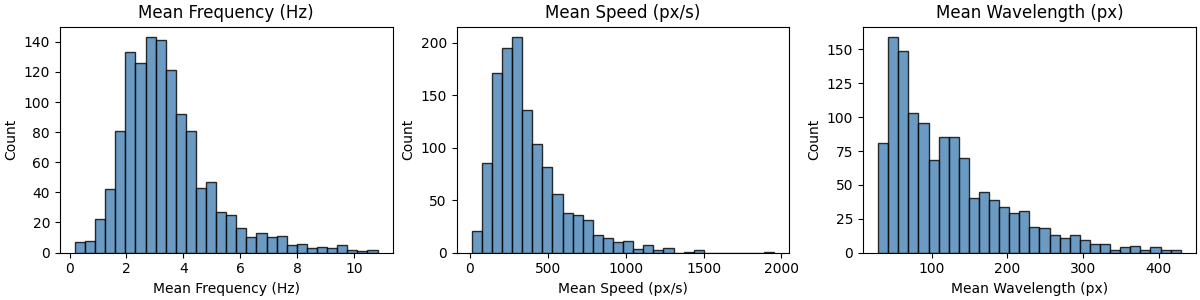

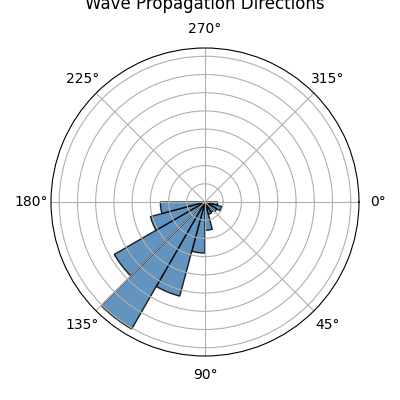

In [ ]:
def plot_wave_event_histograms(events_df):
    """
    Plot histograms of key wave metrics from a day's recordings.

    Parameters
    ----------
    events_df : pandas.DataFrame
        DataFrame containing columns like 'mean_freq_hz', 'mean_speed_px_s', etc.

    Returns
    -------
    None
    """
    metrics = [
        ("mean_freq_hz", "Mean Frequency (Hz)"),
        ("mean_speed_px_s", "Mean Speed (px/s)"),
        ("mean_lambda_px", "Mean Wavelength (px)")
    ]

    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3), constrained_layout=True)

    if n == 1:
        axes = [axes]

    for ax, (col, label) in zip(axes, metrics):
        if col in events_df.columns:
            ax.hist(events_df[col].dropna(), bins=30, color="steelblue", alpha=0.8, edgecolor="black")
            ax.set_xlabel(label)
            ax.set_ylabel("Count")
            ax.set_title(label)
        else:
            ax.set_visible(False)

    plt.show()
